In [3]:
!curl -L "https://app.roboflow.com/ds/3eo8J460oR?key=3bI7qxfQML" > roboflow.zip;
!unzip roboflow.zip;
!rm roboflow.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   904  100   904    0     0   1775      0 --:--:-- --:--:-- --:--:--  1779
100 1676k  100 1676k    0     0  1473k      0  0:00:01  0:00:01 --:--:-- 10.7M
Archive:  roboflow.zip
 extracting: train/images/p22_jpg.rf.c6579787e758c04ea103d545a855f664.jpg  
 extracting: test/images/p20_jpg.rf.6b162ed3a52f3031be3aff6a52dead67.jpg  
 extracting: train/images/p12_jpg.rf.ea5e00247b248dea04f6a2fff954d27d.jpg  
 extracting: test/images/p2_jpg.rf.afaaec0269b5a457015a027e9a62afab.jpg  
 extracting: train/images/p23_jpg.rf.a70a646fb769f80c83c9507109abce93.jpg  
 extracting: train/images/p17_jpg.rf.a74dd950b87f3ed28f42a00554f834a8.jpg  
 extracting: train/images/p21_jpg.rf.3b7f8411619d888d079aa5858c9128cf.jpg  
 extracting: train/images/p19_jpg.rf.d122ab2301df1785d72f71711cd5827c.jpg  
 extracting: train/images/p6_jpg.rf.dd7a4d4759f60cdf191f

In [4]:
!ls

data.yaml  sample_data	test  train  valid


In [5]:
!cat data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['Coins']

roboflow:
  workspace: yasir-lari
  project: coins-dyozc
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/yasir-lari/coins-dyozc/dataset/1

In [6]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.9 MB/s eta 0:00:00


In [7]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.4/107.7 GB disk)


In [8]:
import os

for root, dirs, files in os.walk("/content"):
    if "data.yaml" in files:
        print("FOUND data.yaml at:", root)

FOUND data.yaml at: /content


In [9]:
yaml_path = "/content/data.yaml"

with open(yaml_path, "r") as f:
    data = f.read()

data = data.replace("../train/images", "train/images")
data = data.replace("../valid/images", "valid/images")
data = data.replace("../test/images", "test/images")

with open(yaml_path, "w") as f:
    f.write(data)

print("✅ YAML fixed successfully!")

✅ YAML fixed successfully!


In [10]:
import os

print(os.listdir("/content"))
print(os.listdir("/content/train")[:5])
print(os.listdir("/content/valid")[:5])

['.config', 'data.yaml', 'train', 'test', 'valid']
['labels', 'images']
['labels', 'images']


In [11]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

In [12]:
model.train(
    data="/content/data.yaml",
    epochs=25,
    imgsz=320,
    batch=16
)

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7edb070891c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [13]:
import os

base = "runs/detect/train"
print(os.listdir(base + "/weights"))

['last.pt', 'best.pt']


In [14]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

In [23]:
from google.colab import files
uploaded = files.upload()

Saving p21.jpg to p21.jpg


In [24]:
image_path = list(uploaded.keys())[0]
print("Using image:", image_path)

Using image: p21.jpg


In [25]:
results = model.predict(source=image_path, conf=0.25)


image 1/1 /content/p21.jpg: 256x320 2 Coinss, 55.0ms
Speed: 1.5ms preprocess, 55.0ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 320)


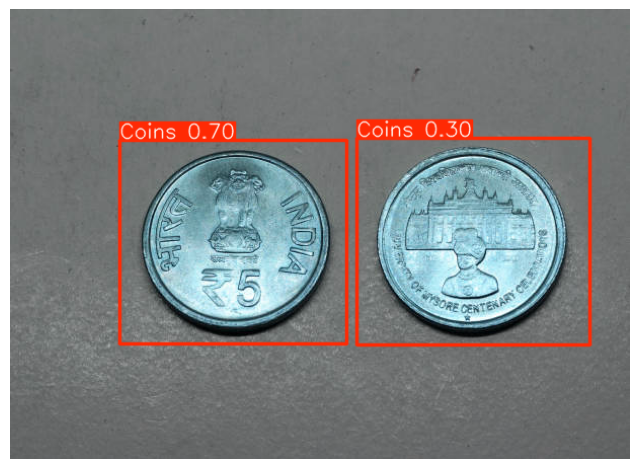

In [26]:
from matplotlib import pyplot as plt

annotated_img = results[0].plot()

plt.figure(figsize=(8,8))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()